In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import mlacca_functions as mlcf

In [2]:
def rectangle(ax,p1,p2,**kwargs):
    h = p2[1]-p2[0]
    w = p1[1]-p1[0]
    rect=plt.Rectangle((p1[0],p2[0]),w,h,**kwargs)
    ax.add_patch(rect)

ls_dict ={
    'lipid': 'solid', 
    'peptide': 'dashdot',

    'carbohydrate': 'dashed',
    'amino_sugar': 'dotted', 
    
    'lignin': (0, (3, 1, 1, 1, 1, 1)), 
    'tannin': (0, (5, 1)),
    'phytochemical': (0, (3, 1, 1, 1))
}

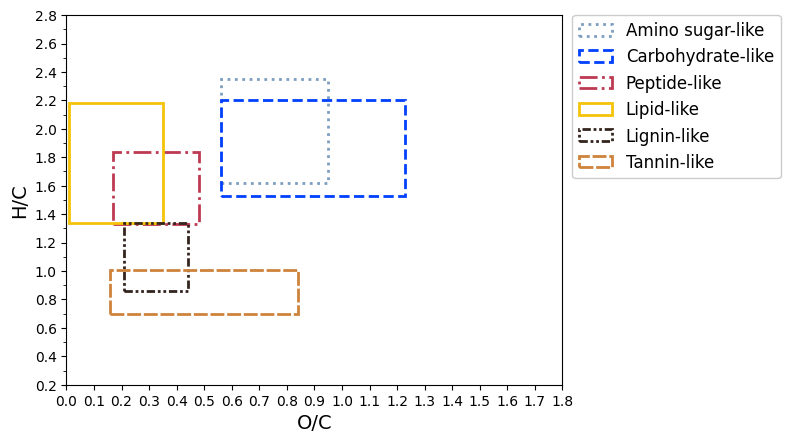

In [3]:
# DBCCR

fig, ax = plt.subplots()

for a in mlcf.laszakovits_mackay_areas:
    label = f'{a.capitalize().replace('_',' ')}-like'
    
    rectangle(ax,mlcf.laszakovits_mackay_areas[a]['O/C'],mlcf.laszakovits_mackay_areas[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a],label=label,ls=ls_dict[a],lw=2)

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
ax.set_xlim(0,1.8)
ax.set_ylim(0.2,2.8)

ax.set_xticks(np.arange(np.min(ax.get_xlim()),np.max(ax.get_xlim())+1e-8,0.1))
ax.set_yticks(np.arange(np.min(ax.get_ylim()),np.max(ax.get_ylim())+1e-8,0.2))

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
fig.savefig('data\\plots\\van_krevelens\\l&m.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')

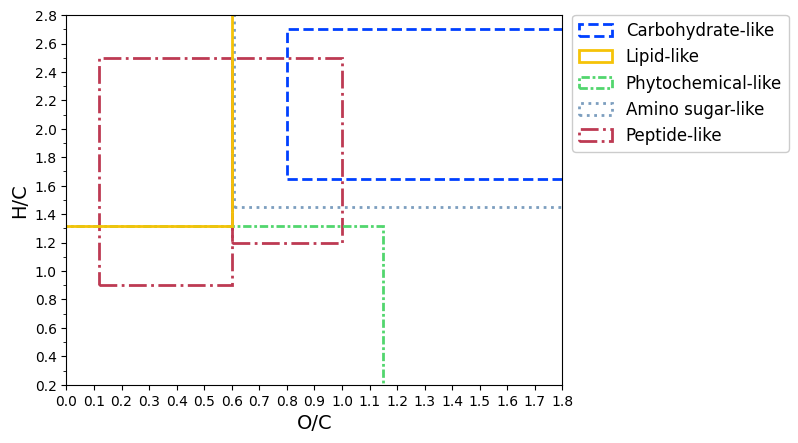

In [4]:
# MSCC

fig, ax = plt.subplots()
zorder = 0
for a in mlcf.rivasubach_areas:
    label = f'{a.capitalize().replace('_',' ').replace('1','').replace('2','')}-like' if '2' not in a else None
    
    rectangle(ax,mlcf.rivasubach_areas[a]['O/C'],mlcf.rivasubach_areas[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a.replace('1','').replace('2','')],label=label,ls=ls_dict[a.replace('1','').replace('2','')],lw=2,zorder=zorder)
    
    zorder -= 1

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
ax.set_xlim(0,1.8)
ax.set_ylim(0.2,2.8)

ax.set_xticks(np.arange(np.min(ax.get_xlim()),np.max(ax.get_xlim())+1e-8,0.1))
ax.set_yticks(np.arange(np.min(ax.get_ylim()),np.max(ax.get_ylim())+1e-8,0.2))

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
fig.savefig('data\\plots\\van_krevelens\\r-u.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')

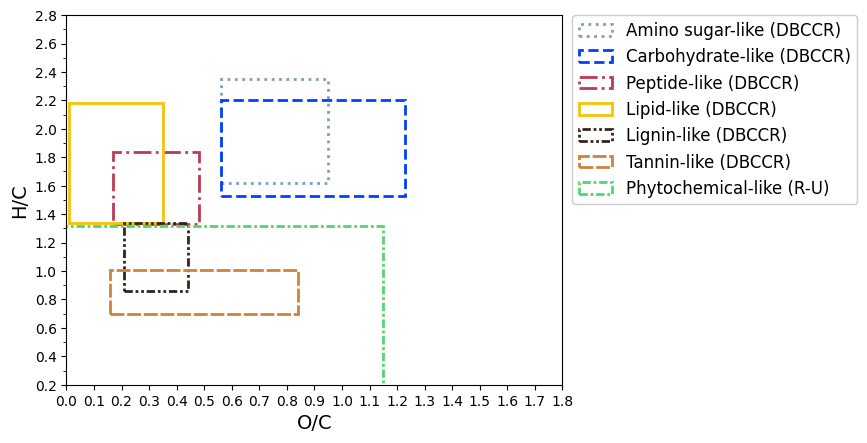

In [5]:
# show overlap of phytochemical and lignin/tannin definitions used

fig, ax = plt.subplots()

areas_compare = {x:mlcf.laszakovits_mackay_areas[x] for x in mlcf.laszakovits_mackay_areas}
areas_compare['phytochemical'] = mlcf.rivasubach_areas['phytochemical']

for a in areas_compare:
    label = f'{a.capitalize().replace('_',' ')}-like'
    
    label += ' (DBCCR)' if a in mlcf.laszakovits_mackay_areas else ' (R-U)'

    rectangle(ax,areas_compare[a]['O/C'],areas_compare[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a],label=label,ls=ls_dict[a],lw=2)

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
ax.set_xlim(0,1.8)
ax.set_ylim(0.2,2.8)

ax.set_xticks(np.arange(np.min(ax.get_xlim()),np.max(ax.get_xlim())+1e-8,0.1))
ax.set_yticks(np.arange(np.min(ax.get_ylim()),np.max(ax.get_ylim())+1e-8,0.2))

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(.1))

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
fig.savefig('data\\plots\\van_krevelens\\l&m_and_phytochemical.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')